# Detecção de Área Queimada com Random Forest
**Classificação Binária: Queimado / Não Queimado — Imagens Landsat 8 e 9**

**Pipeline:**
1. Carregamento e EDA das cenas Landsat
2. Construção da matriz de features (B4, B5, B7, NDVI, NBR, dNBR, dNDVI)
3. Validação por blocos espaciais
4. Estratégias para desbalanceamento: `class_weight`, undersampling, SMOTE, SMOTETomek
5. Ajuste de threshold via curva Precision-Recall
6. Avaliação: F2, MCC, Kappa, Curva PR
7. Importância de atributos
8. Parametrização com Randomized Search
9. Modelo final e mapa de predição

## 0. Setup

In [1]:
# Instalar imbalanced-learn se necessário
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import rasterio
from rasterio.plot import show
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, fbeta_score, matthews_corrcoef,
    cohen_kappa_score, accuracy_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score, PrecisionRecallDisplay
)
from sklearn.utils import resample

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

from scipy.stats import randint

np.random.seed(42)
print('Dependências carregadas.')

Dependências carregadas.


## 1. Configuração dos Caminhos

In [2]:
BASE = '/home/matheus-sales/Documents/atividade_reconhecimento/img_landsat'

CENAS = {
    '221_074': {
        'pre_b4'  : f'{BASE}/221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B4.tif',
        'pre_b5'  : f'{BASE}/221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B5.tif',
        'pre_b7'  : f'{BASE}/221_074/img_pre/LC09_L2SP_221074_20240820_20240821_02_T1_SR_B7.tif',
        'pre_ndvi': f'{BASE}/221_074/img_pre/LC09_L2SP_221074_20240820_NDVI.tif',
        'pre_nbr' : f'{BASE}/221_074/img_pre/LC09_L2SP_221074_20240820_NBR.tif',
        'pos_b4'  : f'{BASE}/221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B4.tif',
        'pos_b5'  : f'{BASE}/221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B5.tif',
        'pos_b7'  : f'{BASE}/221_074/img_pos/LC08_L2SP_221074_20240828_20240831_02_T1_SR_B7.tif',
        'pos_ndvi': f'{BASE}/221_074/img_pos/LC08_L2SP_221074_20240828_NDVI.tif',
        'pos_nbr' : f'{BASE}/221_074/img_pos/LC08_L2SP_221074_20240828_NBR.tif',
        'dnbr'    : f'{BASE}/221_074/diferenca_pre_pos/LC09_221074_dif_nbr_pre_pos.tif',
        'dndvi'   : f'{BASE}/221_074/diferenca_pre_pos/LC09_221074_dif_ndvi_pre_pos.tif',
        'mask'    : f'{BASE}/221_074/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif',
    },
    '220_075': {
        'pre_b4'  : f'{BASE}/220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B4.tif',
        'pre_b5'  : f'{BASE}/220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B5.tif',
        'pre_b7'  : f'{BASE}/220_075/img_pre/LC08_L2SP_220075_20240821_20240830_02_T1_SR_B7.tif',
        'pre_ndvi': f'{BASE}/220_075/img_pre/LC08_L2SP_220075_20240821_NDVI.tif',
        'pre_nbr' : f'{BASE}/220_075/img_pre/LC08_L2SP_220075_20240821_NBR.tif',
        'pos_b4'  : f'{BASE}/220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B4.tif',
        'pos_b5'  : f'{BASE}/220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B5.tif',
        'pos_b7'  : f'{BASE}/220_075/img_pos/LC09_L2SP_220075_20240829_20240830_02_T1_SR_B7.tif',
        'pos_ndvi': f'{BASE}/220_075/img_pos/LC09_L2SP_220075_20240829_NDVI.tif',
        'pos_nbr' : f'{BASE}/220_075/img_pos/LC09_L2SP_220075_20240829_NBR.tif',
        'dnbr'    : f'{BASE}/220_075/diferenca_pre_pos/LC08_220075_dif_nbr_pre_pos.tif',
        'dndvi'   : f'{BASE}/220_075/diferenca_pre_pos/LC08_220075_dif_ndvi_pre_pos.tif',
        'mask'    : f'{BASE}/220_075/mascara_0_1/mascara_1_0_areaqueimada_lim_0-65_nbr.tif',
    }
}

FEATURES = ['pre_b4','pre_b5','pre_b7','pre_ndvi','pre_nbr',
            'pos_b4','pos_b5','pos_b7','pos_ndvi','pos_nbr']

NODATA_FLOAT = -3.4028234663852886e+38
NODATA_UINT  = 0

print('Cenas configuradas:', list(CENAS.keys()))
print('Features           :', FEATURES)

Cenas configuradas: ['221_074', '220_075']
Features           : ['pre_b4', 'pre_b5', 'pre_b7', 'pre_ndvi', 'pre_nbr', 'pos_b4', 'pos_b5', 'pos_b7', 'pos_ndvi', 'pos_nbr']


## 2. Funções Utilitárias

In [3]:
def carregar_banda(path, dtype_alvo='float32'):
    """Lê um GeoTIFF e retorna array 2D + metadados."""
    with rasterio.open(path) as src:
        arr  = src.read(1).astype(dtype_alvo)
        meta = src.meta.copy()
        nd   = src.nodata
    return arr, meta, nd


def construir_mascara_valida(cena_dict, shape_ref):
    """Mascara booleana True onde todos os dados são válidos."""
    nrows, ncols = shape_ref
    valida = np.ones((nrows, ncols), dtype=bool)

    # Máscara de rótulo — exclui nodata
    mask_arr, _, _ = carregar_banda(cena_dict['mask'])
    mask_arr = mask_arr[:nrows, :ncols]
    valida &= ~np.isclose(mask_arr, NODATA_FLOAT, atol=1e30)
    valida &= np.isin(mask_arr, [0.0, 1.0])

    # Bandas uint16 — nodata = 0
    for chave in ['pre_b4','pre_b5','pre_b7','pos_b4','pos_b5','pos_b7']:
        arr, _, _ = carregar_banda(cena_dict[chave])
        arr = arr[:nrows, :ncols]
        valida &= (arr != NODATA_UINT)

    # Bandas float — nodata = -3.4e+38
    for chave in ['pre_ndvi','pre_nbr','pos_ndvi','pos_nbr']:
        arr, _, _ = carregar_banda(cena_dict[chave])
        arr = arr[:nrows, :ncols]
        valida &= ~np.isclose(arr, NODATA_FLOAT, atol=1e30)

    return valida


def carregar_cena(nome_cena, n_amostras=150_000, seed=42):
    """
    Carrega uma cena completa.
    Retorna X (features), y (rótulos), coordenadas de pixels e shape original.
    n_amostras: subsample para viabilidade computacional (None = tudo).
    """
    cena = CENAS[nome_cena]

    # Determina shape mínima comum entre todos os arquivos
    shapes = []
    for chave in FEATURES + ['mask']:
        with rasterio.open(cena[chave]) as src:
            shapes.append(src.shape)
    nrows = min(s[0] for s in shapes)
    ncols = min(s[1] for s in shapes)
    shape_ref = (nrows, ncols)

    print(f'  Shape de referência: {shape_ref}')

    # Máscara de pixels válidos
    valida = construir_mascara_valida(cena, shape_ref)
    idx_validos = np.argwhere(valida)  # (N, 2) — linhas e colunas

    # Rótulos
    mask_arr, meta, _ = carregar_banda(cena['mask'])
    mask_arr = mask_arr[:nrows, :ncols]
    y_full   = mask_arr[valida].astype(int)

    # Subsampling estratificado
    rng = np.random.default_rng(seed)
    if n_amostras is not None and len(y_full) > n_amostras:
        idx_0 = np.where(y_full == 0)[0]
        idx_1 = np.where(y_full == 1)[0]
        ratio = len(idx_1) / len(y_full)
        n1 = max(1, int(n_amostras * ratio))
        n0 = n_amostras - n1
        sel_0 = rng.choice(idx_0, size=min(n0, len(idx_0)), replace=False)
        sel_1 = rng.choice(idx_1, size=min(n1, len(idx_1)), replace=False)
        sel   = np.sort(np.concatenate([sel_0, sel_1]))
    else:
        sel = np.arange(len(y_full))

    coords_sel = idx_validos[sel]  # (n_amostras, 2)
    y          = y_full[sel]

    # Carrega features apenas nos pixels selecionados
    X_lista = []
    for chave in FEATURES:
        arr, _, _ = carregar_banda(cena[chave])
        arr = arr[:nrows, :ncols]
        X_lista.append(arr[coords_sel[:, 0], coords_sel[:, 1]])

    X = np.column_stack(X_lista)

    print(f'  Pixels válidos totais: {len(y_full):,}')
    print(f'  Amostras selecionadas: {len(y):,}')
    print(f'  Queimado (1): {y.sum():,} ({100*y.mean():.1f}%)')
    print(f'  Não queimado (0): {(y==0).sum():,} ({100*(y==0).mean():.1f}%)')

    return X, y, coords_sel, shape_ref, meta


def avaliar(y_true, y_pred, y_prob=None, nome='Modelo', threshold=0.5):
    """Calcula e exibe todas as métricas relevantes."""
    cm    = confusion_matrix(y_true, y_pred)
    oa    = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    f2    = fbeta_score(y_true, y_pred, beta=2)
    mcc   = matthews_corrcoef(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"\n{'='*50}")
    print(f"  {nome}  (threshold={threshold:.2f})")
    print(f"{'='*50}")
    print(f"  OA        : {oa:.4f}")
    print(f"  Kappa     : {kappa:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  F2        : {f2:.4f}")
    print(f"  MCC       : {mcc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    if y_prob is not None:
        auprc = average_precision_score(y_true, y_prob)
        print(f"  AUPRC     : {auprc:.4f}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

    return {'OA': oa, 'Kappa': kappa, 'F1': f1, 'F2': f2,
            'MCC': mcc, 'Precision': precision, 'Recall': recall}


print('Funções definidas.')

Funções definidas.


## 3. Carregamento e Análise Exploratória

In [4]:
print('Carregando cena 221_074...')
X_A, y_A, coords_A, shape_A, meta_A = carregar_cena('221_074', n_amostras=150_000)

print('\nCarregando cena 220_075...')
X_B, y_B, coords_B, shape_B, meta_B = carregar_cena('220_075', n_amostras=150_000)

Carregando cena 221_074...
  Shape de referência: (7821, 7721)
  Pixels válidos totais: 39,660,751
  Amostras selecionadas: 150,000
  Queimado (1): 7,210 (4.8%)
  Não queimado (0): 142,790 (95.2%)

Carregando cena 220_075...
  Shape de referência: (7671, 7581)
  Pixels válidos totais: 40,263,615
  Amostras selecionadas: 150,000
  Queimado (1): 11,888 (7.9%)
  Não queimado (0): 138,112 (92.1%)


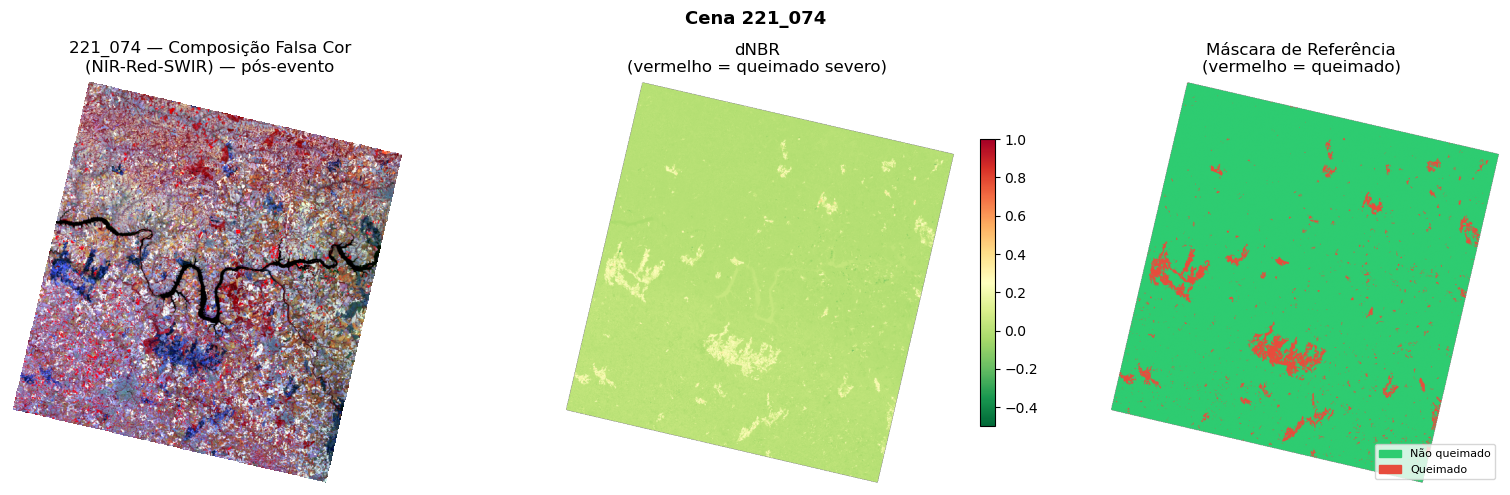

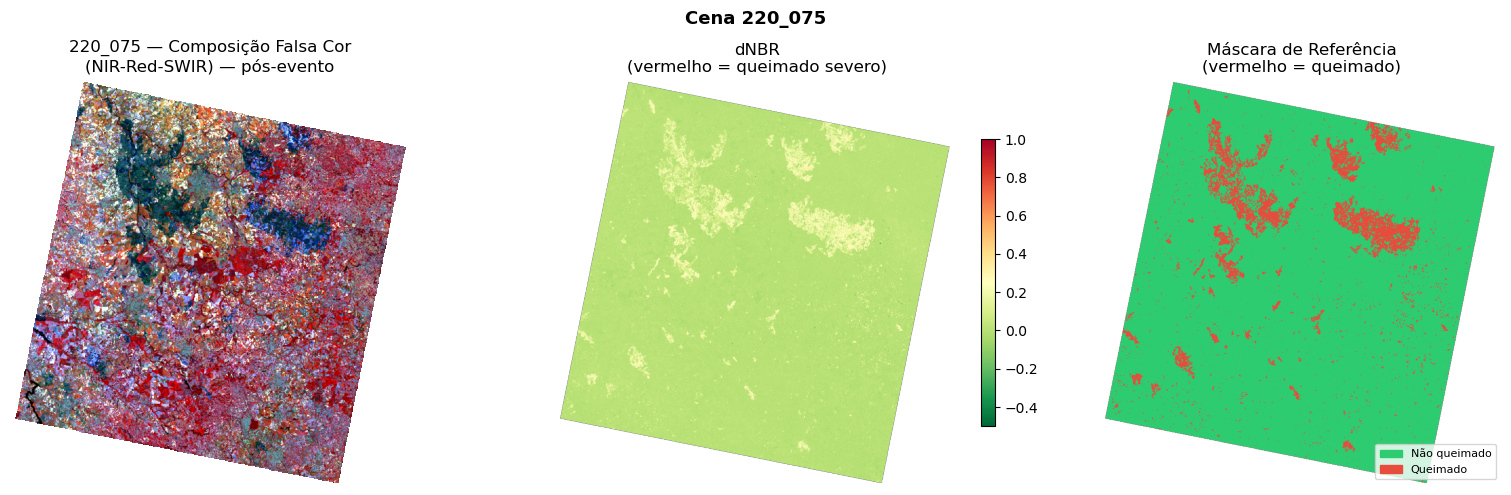

In [5]:
# Visualização: composição colorida e máscara — cena 221_074
def plotar_cena(nome_cena, shape_ref, title_prefix=''):
    cena = CENAS[nome_cena]
    nrows, ncols = shape_ref

    with rasterio.open(cena['pos_b4']) as src:
        b4 = src.read(1, out_shape=(1, nrows//10, ncols//10)).squeeze().astype(float)
    with rasterio.open(cena['pos_b5']) as src:
        b5 = src.read(1, out_shape=(1, nrows//10, ncols//10)).squeeze().astype(float)
    with rasterio.open(cena['pos_b7']) as src:
        b7 = src.read(1, out_shape=(1, nrows//10, ncols//10)).squeeze().astype(float)
    with rasterio.open(cena['dnbr']) as src:
        dnbr = src.read(1, out_shape=(1, nrows//10, ncols//10)).squeeze().astype(float)
    with rasterio.open(cena['mask']) as src:
        mask = src.read(1, out_shape=(1, nrows//10, ncols//10)).squeeze().astype(float)

    def norm(arr):
        arr = np.where(arr <= 0, np.nan, arr)
        p2, p98 = np.nanpercentile(arr, [2, 98])
        return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

    rgb = np.dstack([norm(b5), norm(b4), norm(b7)])  # falsa cor: NIR-R-SWIR

    mask_plot = np.where(np.isclose(mask, -3.4028e+38, atol=1e30), np.nan, mask)
    dnbr_plot = np.where(np.isclose(dnbr, -3.4028e+38, atol=1e30), np.nan, dnbr)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(rgb)
    axes[0].set_title(f'{title_prefix}Composição Falsa Cor\n(NIR-Red-SWIR) — pós-evento')
    axes[0].axis('off')

    im1 = axes[1].imshow(dnbr_plot, cmap='RdYlGn_r', vmin=-0.5, vmax=1.0)
    axes[1].set_title('dNBR\n(vermelho = queimado severo)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.03)

    cmap_mask = plt.cm.colors.ListedColormap(['#2ecc71', '#e74c3c'])
    im2 = axes[2].imshow(mask_plot, cmap=cmap_mask, vmin=0, vmax=1)
    axes[2].set_title('Máscara de Referência\n(vermelho = queimado)')
    axes[2].axis('off')
    patches = [mpatches.Patch(color='#2ecc71', label='Não queimado'),
               mpatches.Patch(color='#e74c3c', label='Queimado')]
    axes[2].legend(handles=patches, loc='lower right', fontsize=8)

    plt.suptitle(f'Cena {nome_cena}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plotar_cena('221_074', shape_A, '221_074 — ')
plotar_cena('220_075', shape_B, '220_075 — ')

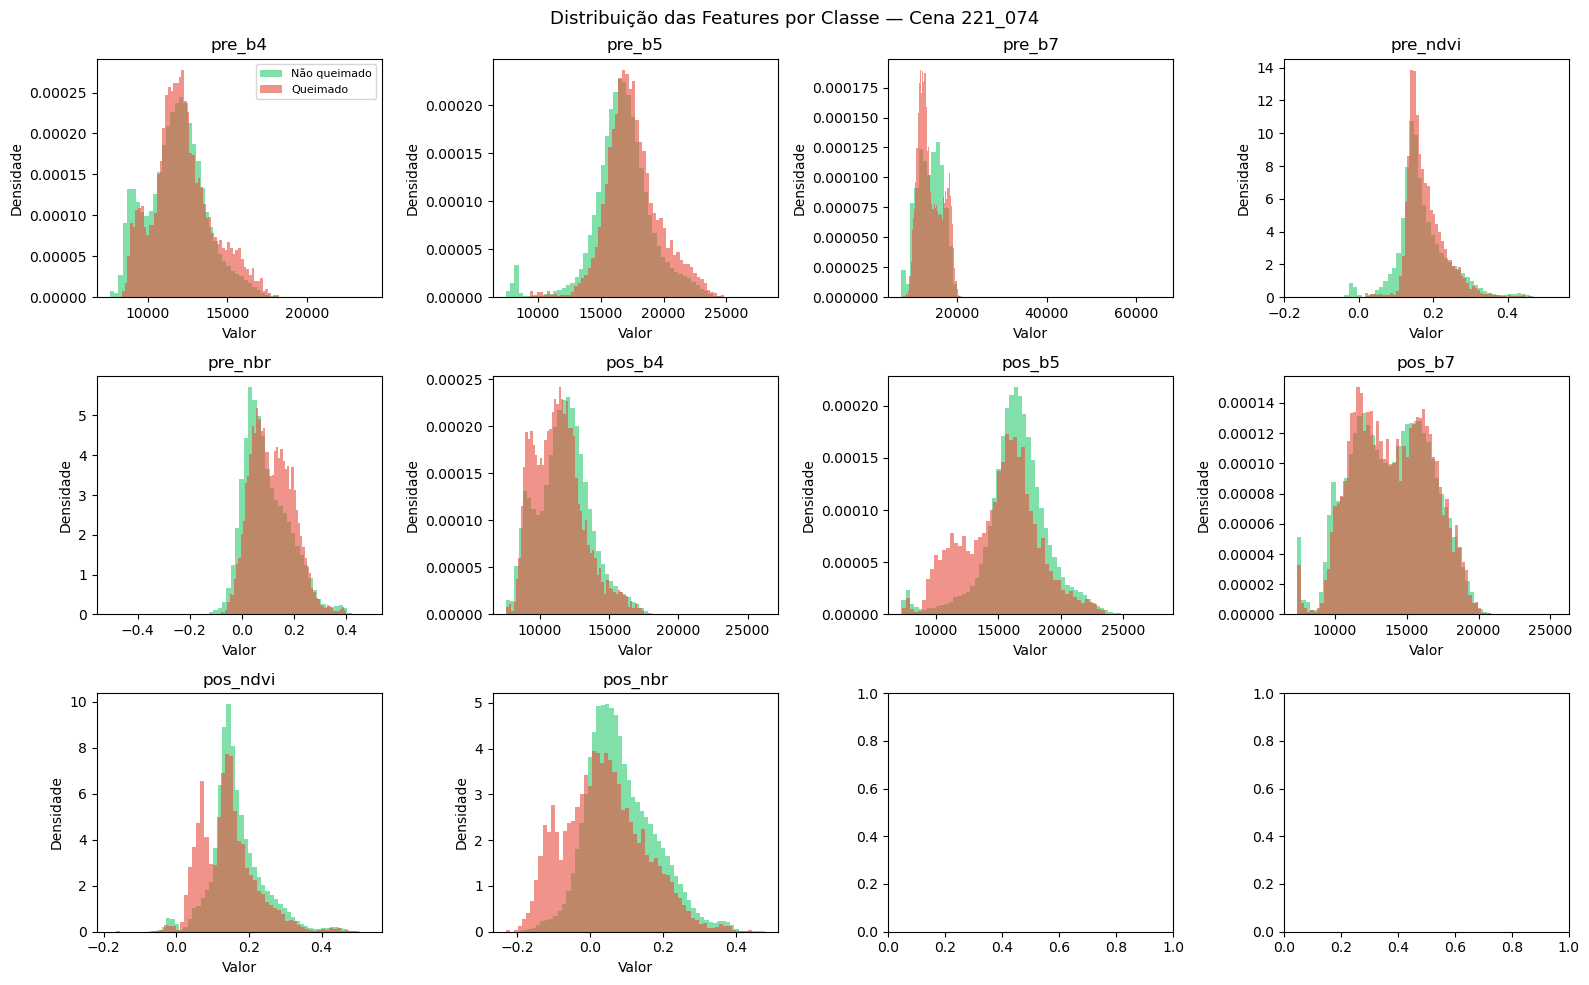

In [6]:
# Distribuição das features por classe
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for cls, cor, label in [(0, '#2ecc71', 'Não queimado'), (1, '#e74c3c', 'Queimado')]:
        dados = X_A[y_A == cls, i]
        ax.hist(dados, bins=60, alpha=0.6, color=cor, label=label, density=True)
    ax.set_title(feat)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidade')
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Distribuição das Features por Classe — Cena 221_074', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Validação por Blocos Espaciais

Divisão aleatória de pixels vaza informação espacial (pixels vizinhos são dependentes).
A solução é dividir a imagem em blocos geográficos e usar alguns para treino e outros para teste.

In [7]:
def blocos_espaciais(coords, shape, n_blocos_lado=4, frac_teste=0.25, seed=42):
    """
    Divide pixels em blocos espaciais e retorna índices de treino/teste.
    n_blocos_lado: grid n x n (ex: 4 → 16 blocos)
    """
    nrows, ncols = shape
    n_blocos = n_blocos_lado ** 2

    # Atribui cada pixel ao seu bloco
    bloco_linha = (coords[:, 0] / nrows * n_blocos_lado).astype(int).clip(0, n_blocos_lado-1)
    bloco_col   = (coords[:, 1] / ncols * n_blocos_lado).astype(int).clip(0, n_blocos_lado-1)
    bloco_id    = bloco_linha * n_blocos_lado + bloco_col  # 0..n_blocos-1

    # Sorteia blocos para teste
    rng = np.random.default_rng(seed)
    todos_blocos   = np.arange(n_blocos)
    n_teste        = max(1, int(n_blocos * frac_teste))
    blocos_teste   = rng.choice(todos_blocos, size=n_teste, replace=False)
    blocos_treino  = np.setdiff1d(todos_blocos, blocos_teste)

    idx_treino = np.where(np.isin(bloco_id, blocos_treino))[0]
    idx_teste  = np.where(np.isin(bloco_id, blocos_teste))[0]

    print(f'  Blocos treino: {sorted(blocos_treino.tolist())}')
    print(f'  Blocos teste : {sorted(blocos_teste.tolist())}')
    print(f'  Pixels treino: {len(idx_treino):,} | Pixels teste: {len(idx_teste):,}')

    return idx_treino, idx_teste, bloco_id


print('--- Cena 221_074 ---')
idx_tr_A, idx_te_A, bloco_id_A = blocos_espaciais(coords_A, shape_A, n_blocos_lado=4)

X_tr, y_tr = X_A[idx_tr_A], y_A[idx_tr_A]
X_te, y_te = X_A[idx_te_A], y_A[idx_te_A]

print(f'\nQueimado no treino : {y_tr.mean():.2%}')
print(f'Queimado no teste  : {y_te.mean():.2%}')

--- Cena 221_074 ---
  Blocos treino: [0, 2, 3, 4, 5, 6, 8, 11, 12, 13, 14, 15]
  Blocos teste : [1, 7, 9, 10]
  Pixels treino: 98,647 | Pixels teste: 51,353

Queimado no treino : 4.56%
Queimado no teste  : 5.29%


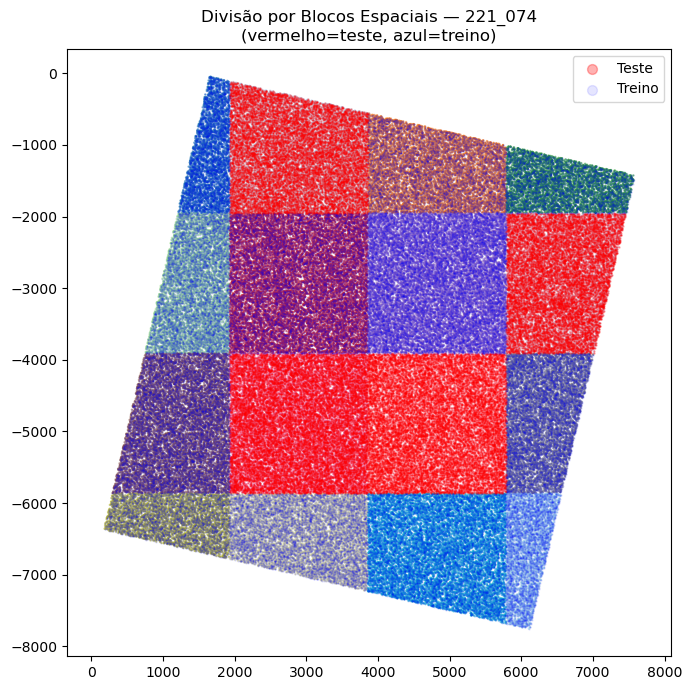

In [8]:
# Visualiza os blocos espaciais
fig, ax = plt.subplots(figsize=(7, 7))
cores = np.where(np.isin(bloco_id_A, [b for b in np.unique(bloco_id_A) if b in
         np.unique(bloco_id_A[np.isin(bloco_id_A, np.unique(bloco_id_A[idx_te_A]))])]), 1, 0)

scatter = ax.scatter(coords_A[:, 1], -coords_A[:, 0], c=bloco_id_A,
                     cmap='tab20', s=0.5, alpha=0.5)

# Destaca pixels de teste
ax.scatter(coords_A[idx_te_A, 1], -coords_A[idx_te_A, 0],
           c='red', s=0.5, alpha=0.3, label='Teste')
ax.scatter(coords_A[idx_tr_A, 1], -coords_A[idx_tr_A, 0],
           c='blue', s=0.5, alpha=0.1, label='Treino')
ax.set_title('Divisão por Blocos Espaciais — 221_074\n(vermelho=teste, azul=treino)')
ax.legend(markerscale=10, fontsize=10)
ax.axis('equal')
plt.tight_layout()
plt.show()

## 5. Estratégias para Desbalanceamento

Desbalanceamento ~19:1 (não queimado:queimado). Comparamos quatro abordagens.

In [9]:
resultados = {}

# ── Estratégia 1: RF padrão (sem tratar desbalanceamento) ──────────────────
print('\n[1/4] RF sem tratamento (baseline)...')
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_tr, y_tr)
y_pred_base = rf_base.predict(X_te)
y_prob_base = rf_base.predict_proba(X_te)[:, 1]
resultados['Sem tratamento'] = avaliar(y_te, y_pred_base, y_prob_base, 'Sem tratamento')

# ── Estratégia 2: class_weight='balanced' ──────────────────────────────────
print('\n[2/4] RF class_weight=balanced...')
rf_bal = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
rf_bal.fit(X_tr, y_tr)
y_pred_bal = rf_bal.predict(X_te)
y_prob_bal = rf_bal.predict_proba(X_te)[:, 1]
resultados['class_weight=balanced'] = avaliar(y_te, y_pred_bal, y_prob_bal, 'class_weight=balanced')


[1/4] RF sem tratamento (baseline)...

  Sem tratamento  (threshold=0.50)
  OA        : 0.9472
  Kappa     : 0.0297
  F1        : 0.0328
  F2        : 0.0210
  MCC       : 0.0882
  Precision : 0.5349
  Recall    : 0.0169
  AUPRC     : 0.2016
  TP=46  FP=40  FN=2669  TN=48598

[2/4] RF class_weight=balanced...

  class_weight=balanced  (threshold=0.50)
  OA        : 0.9474
  Kappa     : 0.0239
  F1        : 0.0260
  F2        : 0.0165
  MCC       : 0.0862
  Precision : 0.6316
  Recall    : 0.0133
  AUPRC     : 0.1913
  TP=36  FP=21  FN=2679  TN=48617


In [10]:
# ── Estratégia 3: Undersampling da classe majoritária ──────────────────────
print('[3/4] Undersampling + RF...')
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_tr, y_tr)
print(f'  Após undersampling: {np.bincount(y_under)}')

rf_under = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_under.fit(X_under, y_under)
y_pred_under = rf_under.predict(X_te)
y_prob_under = rf_under.predict_proba(X_te)[:, 1]
resultados['Undersampling'] = avaliar(y_te, y_pred_under, y_prob_under, 'Undersampling')

# ── Estratégia 4: SMOTE ────────────────────────────────────────────────────
print('\n[4/4] SMOTE + RF...')
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_tr, y_tr)
print(f'  Após SMOTE: {np.bincount(y_smote)}')

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_smote, y_smote)
y_pred_smote = rf_smote.predict(X_te)
y_prob_smote = rf_smote.predict_proba(X_te)[:, 1]
resultados['SMOTE'] = avaliar(y_te, y_pred_smote, y_prob_smote, 'SMOTE')

[3/4] Undersampling + RF...
  Após undersampling: [4495 4495]

  Undersampling  (threshold=0.50)
  OA        : 0.6999
  Kappa     : 0.1215
  F1        : 0.2014
  F2        : 0.3540
  MCC       : 0.1984
  Precision : 0.1172
  Recall    : 0.7157
  AUPRC     : 0.2155
  TP=1943  FP=14640  FN=772  TN=33998

[4/4] SMOTE + RF...
  Após SMOTE: [94152 94152]

  SMOTE  (threshold=0.50)
  OA        : 0.9082
  Kappa     : 0.1717
  F1        : 0.2200
  F2        : 0.2343
  MCC       : 0.1727
  Precision : 0.1996
  Recall    : 0.2449
  AUPRC     : 0.1539
  TP=665  FP=2666  FN=2050  TN=45972


In [11]:
# SMOTETomek
print('SMOTETomek + RF...')
smt = SMOTETomek(random_state=42)
X_smt, y_smt = smt.fit_resample(X_tr, y_tr)
print(f'  Após SMOTETomek: {np.bincount(y_smt)}')

rf_smt = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smt.fit(X_smt, y_smt)
y_pred_smt = rf_smt.predict(X_te)
y_prob_smt = rf_smt.predict_proba(X_te)[:, 1]
resultados['SMOTETomek'] = avaliar(y_te, y_pred_smt, y_prob_smt, 'SMOTETomek')

SMOTETomek + RF...
  Após SMOTETomek: [93846 93846]

  SMOTETomek  (threshold=0.50)
  OA        : 0.9083
  Kappa     : 0.1721
  F1        : 0.2203
  F2        : 0.2345
  MCC       : 0.1731
  Precision : 0.2002
  Recall    : 0.2449
  AUPRC     : 0.1580
  TP=665  FP=2657  FN=2050  TN=45981



=== Comparação das Estratégias (ordenado por F1) ===
                           F1      F2     MCC   Kappa  Precision  Recall      OA
SMOTETomek             0.2203  0.2345  0.1731  0.1721     0.2002  0.2449  0.9083
SMOTE                  0.2200  0.2343  0.1727  0.1717     0.1996  0.2449  0.9082
Undersampling          0.2014  0.3540  0.1984  0.1215     0.1172  0.7157  0.6999
Sem tratamento         0.0328  0.0210  0.0882  0.0297     0.5349  0.0169  0.9472
class_weight=balanced  0.0260  0.0165  0.0862  0.0239     0.6316  0.0133  0.9474


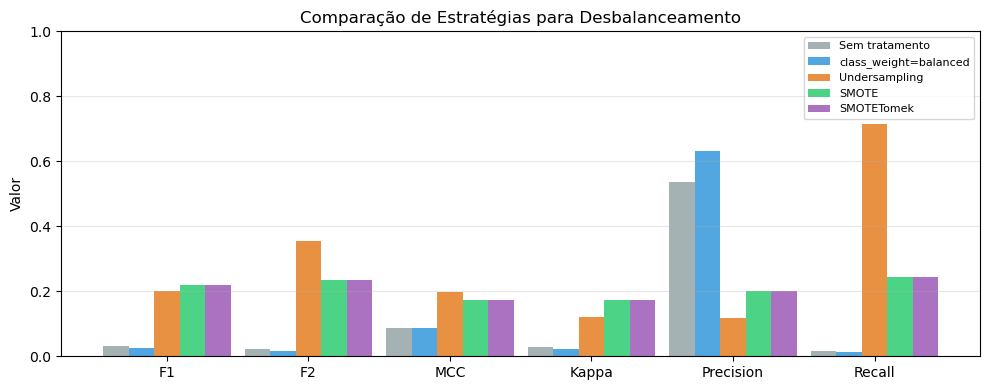

In [12]:
# Tabela comparativa
df_res = pd.DataFrame(resultados).T[['F1','F2','MCC','Kappa','Precision','Recall','OA']]
df_res = df_res.astype(float).round(4)
df_res_sorted = df_res.sort_values('F1', ascending=False)

print('\n=== Comparação das Estratégias (ordenado por F1) ===')
print(df_res_sorted.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
metricas_plot = ['F1', 'F2', 'MCC', 'Kappa', 'Precision', 'Recall']
x = np.arange(len(metricas_plot))
width = 0.18
cores_bar = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for i, (nome, row) in enumerate(df_res.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metricas_plot], width, label=nome, color=cores_bar[i], alpha=0.85)

ax.set_xticks(x + width*2)
ax.set_xticklabels(metricas_plot)
ax.set_ylabel('Valor')
ax.set_title('Comparação de Estratégias para Desbalanceamento')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Ajuste de Threshold via Curva Precision-Recall

Por padrão o RF usa `threshold=0.5`. Para área queimada, **recall é mais crítico** (falso negativo = área queimada não detectada). Otimizamos o threshold via F2.

=== Ajuste de threshold F1 — class_weight=balanced ===


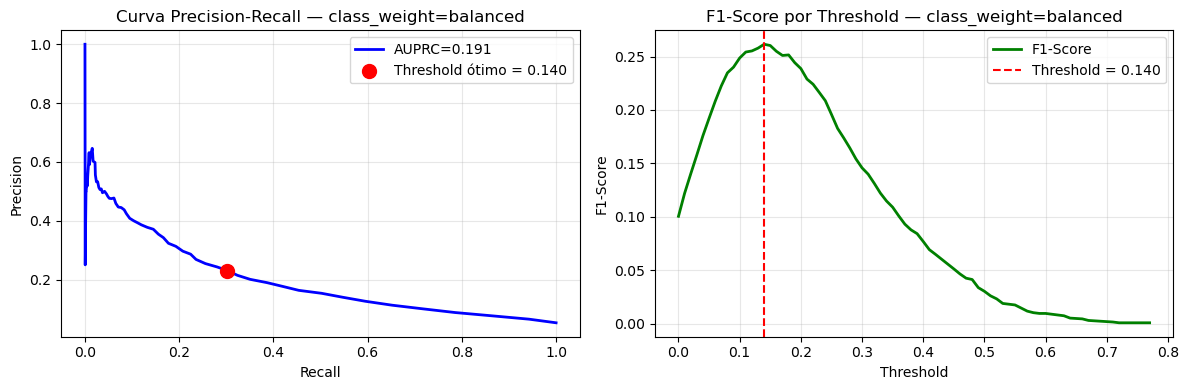

Threshold ótimo (F1): 0.1400  →  F1 = 0.2615

  balanced + threshold=0.140  (threshold=0.14)
  OA        : 0.9098
  Kappa     : 0.2144
  F1        : 0.2615
  F2        : 0.2844
  MCC       : 0.2166
  Precision : 0.2305
  Recall    : 0.3020
  AUPRC     : 0.1913
  TP=820  FP=2737  FN=1895  TN=45901


In [13]:
def otimizar_threshold(y_true, y_prob, beta=1, modelo_nome='Modelo'):
    precision_arr, recall_arr, thresholds = precision_recall_curve(y_true, y_prob)

    # F-beta para cada threshold
    denom  = beta**2 * precision_arr + recall_arr
    fbeta  = np.where(denom > 0,
                      (1 + beta**2) * precision_arr * recall_arr / denom, 0)

    idx_best  = np.argmax(fbeta[:-1])   # exclui o último (sem threshold)
    thr_best  = thresholds[idx_best]
    fbeta_best = fbeta[idx_best]

    # Curva PR
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(recall_arr, precision_arr, 'b-', lw=2, label=f'AUPRC={average_precision_score(y_true, y_prob):.3f}')
    axes[0].scatter(recall_arr[idx_best], precision_arr[idx_best], c='red', s=100, zorder=5,
                    label=f'Threshold ótimo = {thr_best:.3f}')
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')
    axes[0].set_title(f'Curva Precision-Recall — {modelo_nome}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(thresholds, fbeta[:-1], 'g-', lw=2, label=f'F{beta}-Score')
    axes[1].axvline(thr_best, color='red', linestyle='--', label=f'Threshold = {thr_best:.3f}')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel(f'F{beta}-Score')
    axes[1].set_title(f'F{beta}-Score por Threshold — {modelo_nome}')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Threshold ótimo (F{beta}): {thr_best:.4f}  →  F{beta} = {fbeta_best:.4f}')
    return thr_best


# Usa o melhor modelo da etapa anterior (class_weight=balanced como baseline)
print('=== Ajuste de threshold F1 — class_weight=balanced ===')
thr_opt_bal = otimizar_threshold(y_te, y_prob_bal, beta=1, modelo_nome='class_weight=balanced')

y_pred_thr = (y_prob_bal >= thr_opt_bal).astype(int)
resultados['balanced + thr. ótimo'] = avaliar(
    y_te, y_pred_thr, y_prob_bal,
    f'balanced + threshold={thr_opt_bal:.3f}', threshold=thr_opt_bal
)

## 7. Matrizes de Confusão Comparativas

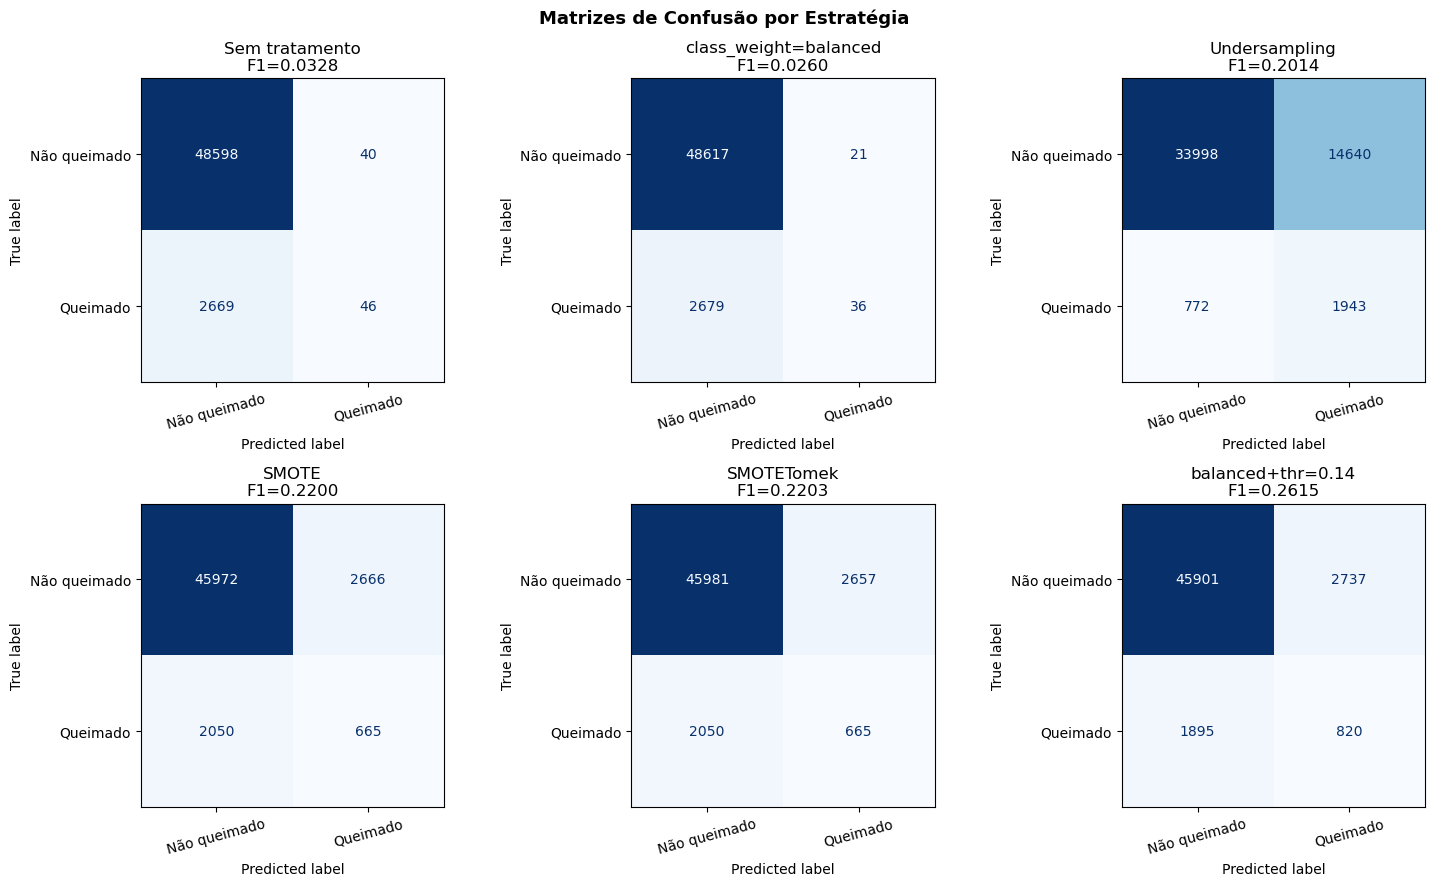

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

configs = [
    ('Sem tratamento',        y_pred_base),
    ('class_weight=balanced', y_pred_bal),
    ('Undersampling',         y_pred_under),
    ('SMOTE',                 y_pred_smote),
    ('SMOTETomek',            y_pred_smt),
    (f'balanced+thr={thr_opt_bal:.2f}', y_pred_thr),
]

labels = ['Não queimado', 'Queimado']
for ax, (nome, y_pred) in zip(axes, configs):
    cm = confusion_matrix(y_te, y_pred)
    f1_val = f1_score(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nF1={f1_val:.4f}')
    ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Matrizes de Confusão por Estratégia', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Importância de Atributos

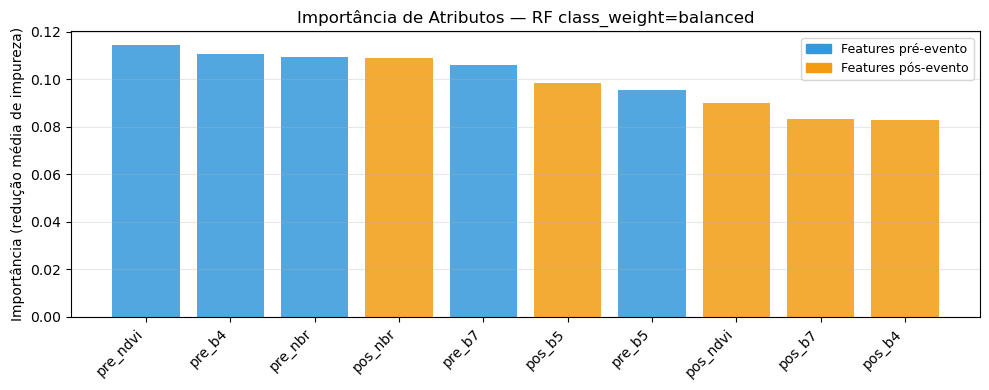

Ranking:
   1. pre_ndvi    : 0.1145
   2. pre_b4      : 0.1106
   3. pre_nbr     : 0.1094
   4. pos_nbr     : 0.1091
   5. pre_b7      : 0.1061
   6. pos_b5      : 0.0985
   7. pre_b5      : 0.0956
   8. pos_ndvi    : 0.0899
   9. pos_b7      : 0.0835
  10. pos_b4      : 0.0828


In [15]:
importancias = rf_bal.feature_importances_
idx_ord = np.argsort(importancias)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
cores_feat = ['#3498db' if 'pre_' in FEATURES[i] else '#f39c12'
              for i in idx_ord]

bars = ax.bar(range(len(FEATURES)), importancias[idx_ord], color=cores_feat, alpha=0.85)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in idx_ord], rotation=45, ha='right')
ax.set_ylabel('Importância (redução média de impureza)')
ax.set_title('Importância de Atributos — RF class_weight=balanced')
ax.grid(axis='y', alpha=0.3)

patches = [
    mpatches.Patch(color='#3498db', label='Features pré-evento'),
    mpatches.Patch(color='#f39c12', label='Features pós-evento'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

print('Ranking:')
for rank, i in enumerate(idx_ord):
    print(f'  {rank+1:2d}. {FEATURES[i]:<12}: {importancias[i]:.4f}')

## 9. Parametrização com Randomized Search

In [16]:
param_dist = {
    'n_estimators'          : randint(100, 400),
    'max_features'          : ['sqrt', 'log2', 0.5],
    'min_samples_leaf'      : randint(1, 15),
    'max_depth'             : [None, 10, 20, 30],
    'min_impurity_decrease' : [0.0, 1e-5, 1e-4],
    'class_weight'          : ['balanced', 'balanced_subsample'],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=30,
    scoring='f1',        # F1 como métrica principal de otimização
    cv=cv_strat,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs.fit(X_tr, y_tr)

print(f'\nMelhores parâmetros : {rs.best_params_}')
print(f'Melhor F1 (CV)      : {rs.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Melhores parâmetros : {'class_weight': 'balanced', 'max_depth': 30, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0001, 'min_samples_leaf': 11, 'n_estimators': 171}
Melhor F1 (CV)      : 0.2211


=== Modelo Otimizado (Randomized Search) — threshold=0.5 ===

  RF Otimizado (thr=0.5)  (threshold=0.50)
  OA        : 0.8873
  Kappa     : 0.2476
  F1        : 0.3011
  F2        : 0.3794
  MCC       : 0.2666
  Precision : 0.2240
  Recall    : 0.4589
  AUPRC     : 0.2600
  TP=1246  FP=4316  FN=1469  TN=44322

=== Ajuste de threshold no modelo otimizado ===


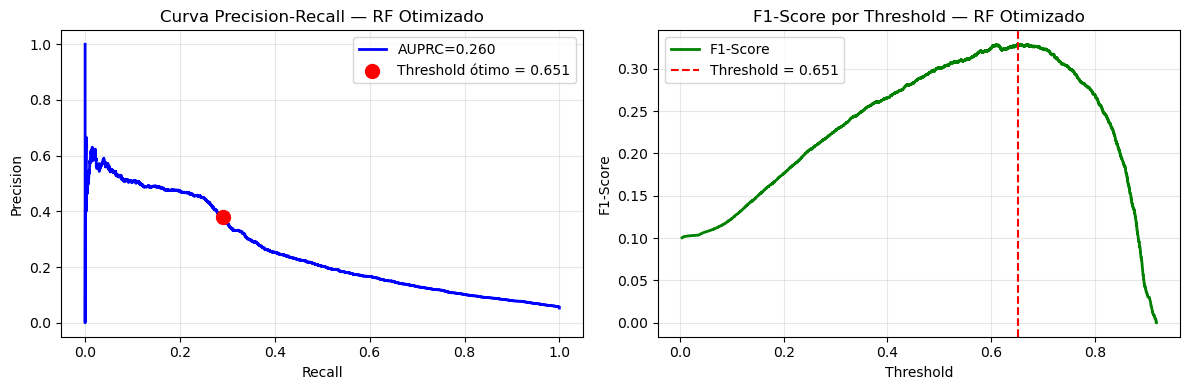

Threshold ótimo (F1): 0.6512  →  F1 = 0.3290

  RF Otimizado + threshold=0.651  (threshold=0.65)
  OA        : 0.9372
  Kappa     : 0.2966
  F1        : 0.3290
  F2        : 0.3051
  MCC       : 0.2994
  Precision : 0.3784
  Recall    : 0.2910
  AUPRC     : 0.2600
  TP=790  FP=1298  FN=1925  TN=47340


In [17]:
# Avalia o melhor modelo com threshold otimizado
rf_best = rs.best_estimator_
y_prob_best = rf_best.predict_proba(X_te)[:, 1]

print('=== Modelo Otimizado (Randomized Search) — threshold=0.5 ===')
_ = avaliar(y_te, (y_prob_best >= 0.5).astype(int), y_prob_best, 'RF Otimizado (thr=0.5)')

print('\n=== Ajuste de threshold no modelo otimizado ===')
thr_best_opt = otimizar_threshold(y_te, y_prob_best, beta=1, modelo_nome='RF Otimizado')

y_pred_final = (y_prob_best >= thr_best_opt).astype(int)
resultados['RF Otimizado + thr'] = avaliar(
    y_te, y_pred_final, y_prob_best,
    f'RF Otimizado + threshold={thr_best_opt:.3f}', threshold=thr_best_opt
)

## 10. Validação Cruzada entre Cenas

Treina na cena 221_074 e testa na 220_075 — verifica generalização espacial real.

In [18]:
print('Treinando na 221_074, testando na 220_075...')

rf_cross = RandomForestClassifier(**rs.best_params_, random_state=42, n_jobs=-1)
rf_cross.fit(X_A, y_A)   # treina em toda a cena A

y_prob_cross = rf_cross.predict_proba(X_B)[:, 1]
y_pred_cross = (y_prob_cross >= thr_best_opt).astype(int)

resultados['Cross-cena (221→220)'] = avaliar(
    y_B, y_pred_cross, y_prob_cross,
    f'Cross-cena (221_074 → 220_075)', threshold=thr_best_opt
)

Treinando na 221_074, testando na 220_075...

  Cross-cena (221_074 → 220_075)  (threshold=0.65)
  OA        : 0.9191
  Kappa     : 0.3688
  F1        : 0.4111
  F2        : 0.3763
  MCC       : 0.3739
  Precision : 0.4861
  Recall    : 0.3562
  AUPRC     : 0.4668
  TP=4234  FP=4477  FN=7654  TN=133635


## 11. Resumo Final de Todas as Estratégias

=== Ranking Final (ordenado por F1) ===
                           F1      F2     MCC   Kappa  Precision  Recall      OA
Cross-cena (221→220)   0.4111  0.3763  0.3739  0.3688     0.4861  0.3562  0.9191
RF Otimizado + thr     0.3290  0.3051  0.2994  0.2966     0.3784  0.2910  0.9372
balanced + thr. ótimo  0.2615  0.2844  0.2166  0.2144     0.2305  0.3020  0.9098
SMOTETomek             0.2203  0.2345  0.1731  0.1721     0.2002  0.2449  0.9083
SMOTE                  0.2200  0.2343  0.1727  0.1717     0.1996  0.2449  0.9082
Undersampling          0.2014  0.3540  0.1984  0.1215     0.1172  0.7157  0.6999
Sem tratamento         0.0328  0.0210  0.0882  0.0297     0.5349  0.0169  0.9472
class_weight=balanced  0.0260  0.0165  0.0862  0.0239     0.6316  0.0133  0.9474


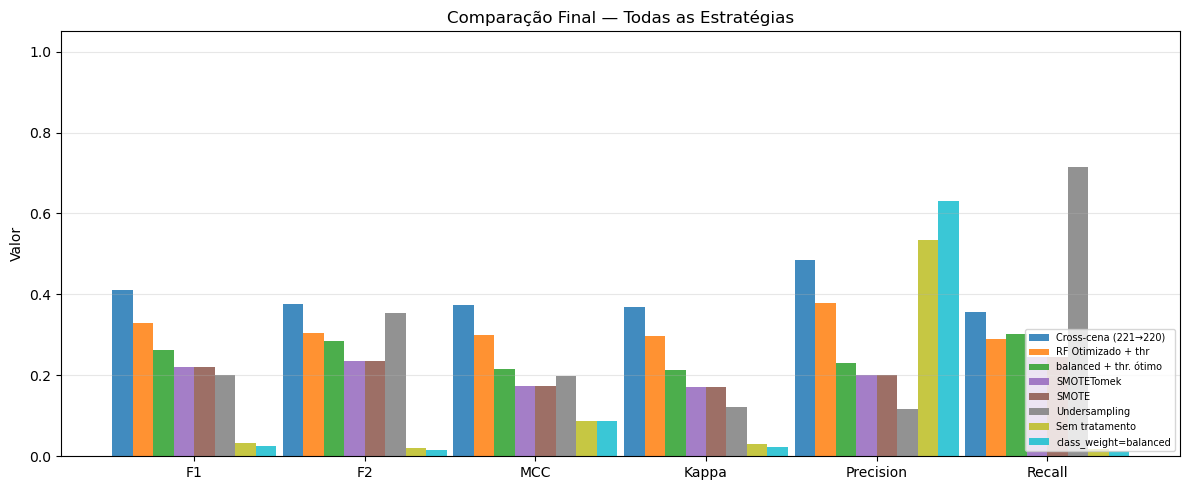

In [19]:
df_final = pd.DataFrame(resultados).T[['F1','F2','MCC','Kappa','Precision','Recall','OA']]
df_final = df_final.astype(float).round(4).sort_values('F1', ascending=False)

print('=== Ranking Final (ordenado por F1) ===')
print(df_final.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
metricas_plot = ['F1', 'F2', 'MCC', 'Kappa', 'Precision', 'Recall']
x     = np.arange(len(metricas_plot))
nmod  = len(df_final)
width = 0.12
cmap  = plt.cm.get_cmap('tab10', nmod)

for i, (nome, row) in enumerate(df_final.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metricas_plot], width,
           label=nome, color=cmap(i), alpha=0.85)

ax.set_xticks(x + width * (nmod-1) / 2)
ax.set_xticklabels(metricas_plot)
ax.set_ylabel('Valor')
ax.set_title('Comparação Final — Todas as Estratégias')
ax.legend(fontsize=7, loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Mapa de Predição na Imagem Completa

In [20]:
def gerar_mapa_predicao(nome_cena, modelo, threshold, shape_ref, escala=5):
    """
    Aplica o modelo em toda a cena e gera o mapa de predição.
    Lê as bandas em resolução reduzida (1/escala) para garantir
    cobertura completa do mapa sem subamostagem aleatória.
    """
    cena   = CENAS[nome_cena]
    nrows, ncols = shape_ref
    out_rows = nrows // escala
    out_cols = ncols // escala

    # Carrega todas as features na resolução de display
    X_lista = []
    nodata_mask = np.zeros((out_rows, out_cols), dtype=bool)

    for chave in FEATURES:
        with rasterio.open(cena[chave]) as src:
            arr = src.read(1, out_shape=(1, out_rows, out_cols)).squeeze().astype(np.float32)
        # Marca nodata por tipo de banda
        if chave in ['pre_b4', 'pre_b5', 'pre_b7', 'pos_b4', 'pos_b5', 'pos_b7']:
            nodata_mask |= (arr == NODATA_UINT)
        else:
            nodata_mask |= np.isclose(arr, NODATA_FLOAT, atol=1e30)
        X_lista.append(arr)

    # Índices válidos
    valido = ~nodata_mask
    idx_v  = np.argwhere(valido)
    X_pred = np.column_stack([x[idx_v[:, 0], idx_v[:, 1]] for x in X_lista])

    # Predição em batch
    BATCH = 100_000
    probs = np.zeros(len(idx_v), dtype=np.float32)
    for i in range(0, len(idx_v), BATCH):
        probs[i:i+BATCH] = modelo.predict_proba(X_pred[i:i+BATCH])[:, 1]

    pred_map = np.full((out_rows, out_cols), np.nan)
    pred_map[idx_v[:, 0], idx_v[:, 1]] = (probs >= threshold).astype(float)

    return pred_map, probs, idx_v


print('Gerando mapa de predição para a cena 221_074...')
pred_map_A, probs_A, idx_A = gerar_mapa_predicao(
    '221_074', rf_best, thr_best_opt, shape_A, escala=5
)

Gerando mapa de predição para a cena 221_074...


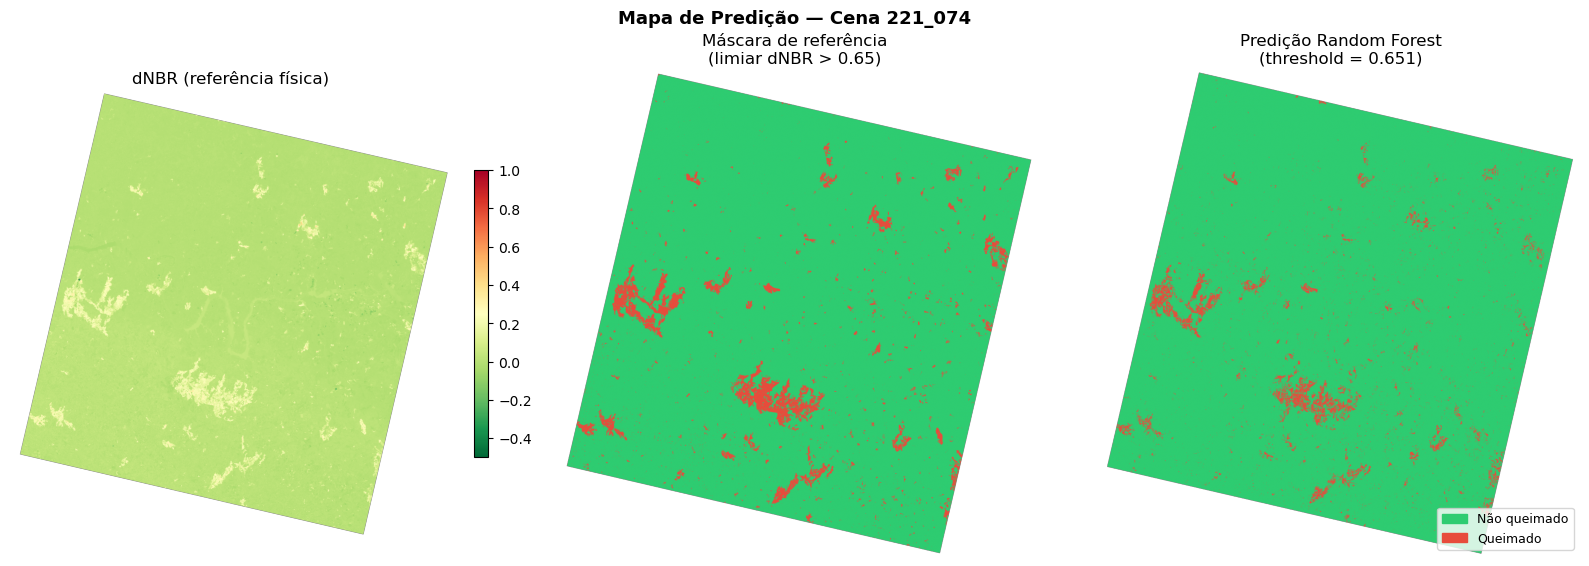

In [21]:
# Carrega máscara de referência para comparação
with rasterio.open(CENAS['221_074']['mask']) as src:
    mask_ref = src.read(1, out_shape=(1, shape_A[0]//5, shape_A[1]//5)).squeeze().astype(float)
    mask_ref = np.where(np.isclose(mask_ref, NODATA_FLOAT, atol=1e30), np.nan, mask_ref)

# dNBR para contexto
with rasterio.open(CENAS['221_074']['dnbr']) as src:
    dnbr_ref = src.read(1, out_shape=(1, shape_A[0]//5, shape_A[1]//5)).squeeze().astype(float)
    dnbr_ref = np.where(np.isclose(dnbr_ref, NODATA_FLOAT, atol=1e30), np.nan, dnbr_ref)

pred_small = pred_map_A

cmap_bw = plt.cm.colors.ListedColormap(['#2ecc71', '#e74c3c'])

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

im0 = axes[0].imshow(dnbr_ref, cmap='RdYlGn_r', vmin=-0.5, vmax=1.0)
axes[0].set_title('dNBR (referência física)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.03)

axes[1].imshow(mask_ref, cmap=cmap_bw, vmin=0, vmax=1)
axes[1].set_title('Máscara de referência\n(limiar dNBR > 0.65)')
axes[1].axis('off')

axes[2].imshow(pred_small, cmap=cmap_bw, vmin=0, vmax=1)
axes[2].set_title(f'Predição Random Forest\n(threshold = {thr_best_opt:.3f})')
axes[2].axis('off')

patches = [mpatches.Patch(color='#2ecc71', label='Não queimado'),
           mpatches.Patch(color='#e74c3c', label='Queimado')]
axes[2].legend(handles=patches, loc='lower right', fontsize=9)

plt.suptitle('Mapa de Predição — Cena 221_074', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Análise de Erros: Falsos Positivos e Falsos Negativos

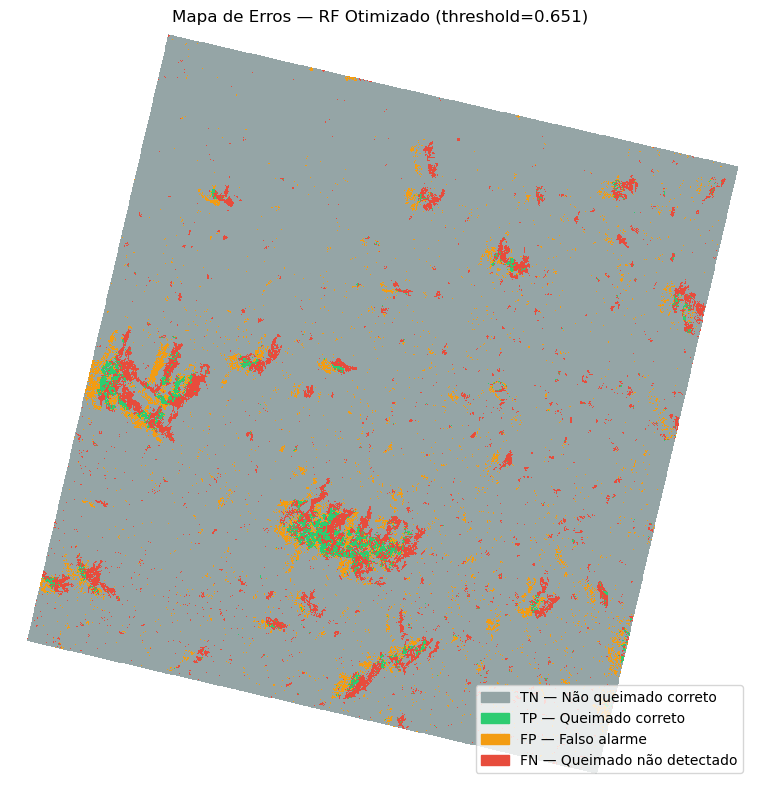

TN: 1,470,429 pixels
TP: 16,252 pixels
FP: 39,328 pixels
FN: 59,905 pixels


In [22]:
# Carrega máscara de referência na resolução completa (subsampled)
with rasterio.open(CENAS['221_074']['mask']) as src:
    mask_full = src.read(1, out_shape=(1, shape_A[0]//5, shape_A[1]//5)).squeeze().astype(float)
    mask_full = np.where(np.isclose(mask_full, NODATA_FLOAT, atol=1e30), np.nan, mask_full)

pred_s  = pred_map_A
ref_s   = mask_full

# Alinha shapes (slicing ::5 vs //5 podem diferir por 1 pixel)
h = min(pred_s.shape[0], ref_s.shape[0])
w = min(pred_s.shape[1], ref_s.shape[1])
pred_s = pred_s[:h, :w]
ref_s  = ref_s[:h, :w]

# Mapa de erros
erro_map = np.full_like(pred_s, np.nan)
valido   = ~np.isnan(pred_s) & ~np.isnan(ref_s)

erro_map[valido & (ref_s == 0) & (pred_s == 0)] = 0   # TN
erro_map[valido & (ref_s == 1) & (pred_s == 1)] = 1   # TP
erro_map[valido & (ref_s == 0) & (pred_s == 1)] = 2   # FP
erro_map[valido & (ref_s == 1) & (pred_s == 0)] = 3   # FN

cmap_erro = plt.cm.colors.ListedColormap(['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(erro_map, cmap=cmap_erro, vmin=0, vmax=3, interpolation='nearest')
ax.set_title(f'Mapa de Erros — RF Otimizado (threshold={thr_best_opt:.3f})', fontsize=12)
ax.axis('off')

patches_erro = [
    mpatches.Patch(color='#95a5a6', label='TN — Não queimado correto'),
    mpatches.Patch(color='#2ecc71', label='TP — Queimado correto'),
    mpatches.Patch(color='#f39c12', label='FP — Falso alarme'),
    mpatches.Patch(color='#e74c3c', label='FN — Queimado não detectado'),
]
ax.legend(handles=patches_erro, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# Contagem de erros
for val, nome in [(0,'TN'), (1,'TP'), (2,'FP'), (3,'FN')]:
    n = np.sum(erro_map == val)
    print(f'{nome}: {n:,} pixels')

## 14. Pós-processamento Morfológico — Redução de Falsos Positivos

Queimadas reais formam manchas contíguas de vários hectares. Falsos positivos costumam ser pixels isolados ou grupos muito pequenos. O filtro morfológico (abertura + área mínima) remove essas ocorrências sem alterar o modelo.

Metrica             Antes     Depois      Delta
TP                 16,252      9,355     -6,897
FP                 39,328     14,076    -25,252
FN                 59,905     66,802     +6,897
TN              1,470,429  1,495,681    +25,252
Precision           0.292      0.399     +0.107
Recall              0.213      0.123     -0.091
F1                  0.247      0.188     -0.059
Reducao de FP   : 64.2%
Variacao Recall : -9.1 pp


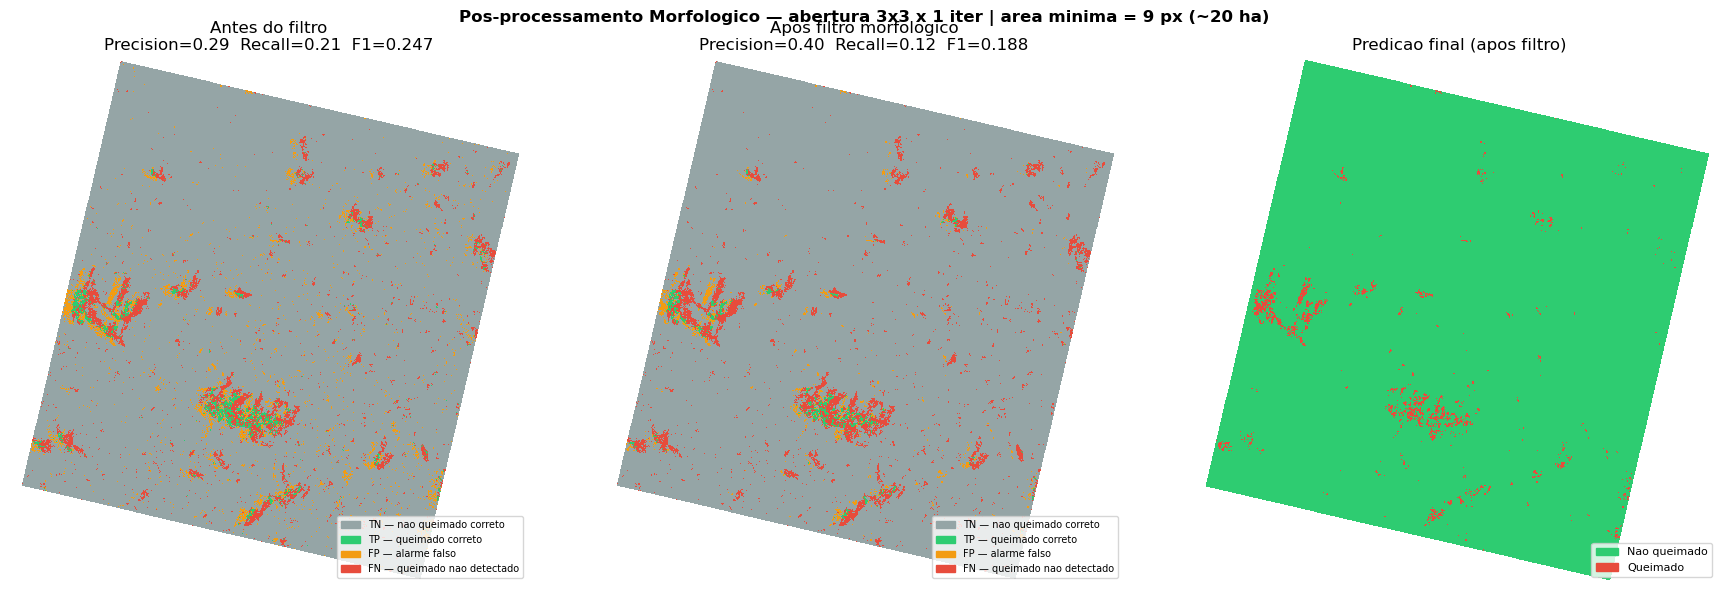

In [23]:
from scipy.ndimage import binary_opening, label as ndlabel

# ── Parâmetros do filtro ───────────────────────────────────
STRUCT_SIZE = 3   # estrutura 3×3 para abertura morfológica
OPEN_ITER   = 1   # iterações de abertura
MIN_AREA    = 9   # tamanho mínimo de patch em pixels (resolução display)
              # escala=5 → cada pixel cobre 150 m → 9 px ≈ 20 ha

# ── 1. Máscara binária (NaN tratado como False) ───────────
valid_mask   = ~np.isnan(pred_map_A)
pred_binary  = np.where(valid_mask, pred_map_A == 1, False)

# ── 2. Abertura morfológica (remove pixels isolados) ──────
struct       = np.ones((STRUCT_SIZE, STRUCT_SIZE), dtype=bool)
pred_opened  = binary_opening(pred_binary, structure=struct, iterations=OPEN_ITER)

# ── 3. Filtro de área mínima (remove patches pequenos) ────
labeled_arr, n_comp = ndlabel(pred_opened)
sizes    = np.bincount(labeled_arr.ravel())
keep     = sizes >= MIN_AREA
keep[0]  = False   # label 0 = background
pred_filtered = keep[labeled_arr]

# ── 4. Reconstrói mapa preservando NaN ───────────────────
pred_map_morph = np.full_like(pred_map_A, np.nan)
pred_map_morph[valid_mask] = pred_filtered[valid_mask].astype(float)

# ── 5. Máscara de referência na mesma resolução ───────────
with rasterio.open(CENAS['221_074']['mask']) as src:
    mask_morph = src.read(1, out_shape=(1, pred_map_A.shape[0], pred_map_A.shape[1])).squeeze().astype(float)
mask_morph = np.where(np.isclose(mask_morph, NODATA_FLOAT, atol=1e30), np.nan, mask_morph)

# ── 6. Função de métricas ─────────────────────────────────
def metricas_mapa(pred_m, ref_m):
    h = min(pred_m.shape[0], ref_m.shape[0])
    w = min(pred_m.shape[1], ref_m.shape[1])
    p, r = pred_m[:h, :w], ref_m[:h, :w]
    val  = ~np.isnan(p) & ~np.isnan(r)
    pf, rf = p[val], r[val]
    TP = int(np.sum((pf == 1) & (rf == 1)))
    FP = int(np.sum((pf == 1) & (rf == 0)))
    FN = int(np.sum((pf == 0) & (rf == 1)))
    TN = int(np.sum((pf == 0) & (rf == 0)))
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_v = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0
    return dict(TP=TP, FP=FP, FN=FN, TN=TN, Precision=prec, Recall=rec, F1=f1_v)

antes  = metricas_mapa(pred_map_A,     mask_morph)
depois = metricas_mapa(pred_map_morph, mask_morph)

# ── 7. Tabela comparativa ─────────────────────────────────
print('=' * 52)
print(f"{'Metrica':<14} {'Antes':>10} {'Depois':>10} {'Delta':>10}")
print('=' * 52)
for k in ['TP', 'FP', 'FN', 'TN', 'Precision', 'Recall', 'F1']:
    a, d = antes[k], depois[k]
    if isinstance(a, int):
        print(f"{k:<14} {a:>10,} {d:>10,} {d-a:>+10,}")
    else:
        print(f"{k:<14} {a:>10.3f} {d:>10.3f} {d-a:>+10.3f}")
print('=' * 52)
fp_red = (1 - depois['FP'] / max(antes['FP'], 1)) * 100
rec_delta = (depois['Recall'] - antes['Recall']) * 100
print(f'Reducao de FP   : {fp_red:.1f}%')
print(f'Variacao Recall : {rec_delta:+.1f} pp')

# ── 8. Visualização comparativa ──────────────────────────
cmap_bw   = plt.cm.colors.ListedColormap(['#2ecc71', '#e74c3c'])
cmap_erro = plt.cm.colors.ListedColormap(['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'])

def mapa_erros_fn(pred_m, ref_m):
    h = min(pred_m.shape[0], ref_m.shape[0])
    w = min(pred_m.shape[1], ref_m.shape[1])
    p, r = pred_m[:h, :w], ref_m[:h, :w]
    em = np.full_like(p, np.nan)
    val = ~np.isnan(p) & ~np.isnan(r)
    em[val & (r == 0) & (p == 0)] = 0
    em[val & (r == 1) & (p == 1)] = 1
    em[val & (r == 0) & (p == 1)] = 2
    em[val & (r == 1) & (p == 0)] = 3
    return em

em_antes  = mapa_erros_fn(pred_map_A,     mask_morph)
em_depois = mapa_erros_fn(pred_map_morph, mask_morph)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(em_antes,  cmap=cmap_erro, vmin=0, vmax=3, interpolation='nearest')
axes[0].set_title(
    f'Antes do filtro\nPrecision={antes["Precision"]:.2f}  Recall={antes["Recall"]:.2f}  F1={antes["F1"]:.3f}')
axes[0].axis('off')

axes[1].imshow(em_depois, cmap=cmap_erro, vmin=0, vmax=3, interpolation='nearest')
axes[1].set_title(
    f'Apos filtro morfologico\nPrecision={depois["Precision"]:.2f}  Recall={depois["Recall"]:.2f}  F1={depois["F1"]:.3f}')
axes[1].axis('off')

axes[2].imshow(pred_map_morph, cmap=cmap_bw, vmin=0, vmax=1, interpolation='nearest')
axes[2].set_title('Predicao final (apos filtro)')
axes[2].axis('off')

patches_erro = [
    mpatches.Patch(color='#95a5a6', label='TN — nao queimado correto'),
    mpatches.Patch(color='#2ecc71', label='TP — queimado correto'),
    mpatches.Patch(color='#f39c12', label='FP — alarme falso'),
    mpatches.Patch(color='#e74c3c', label='FN — queimado nao detectado'),
]
for ax in axes[:2]:
    ax.legend(handles=patches_erro, loc='lower right', fontsize=7)

patches_pred = [mpatches.Patch(color='#2ecc71', label='Nao queimado'),
                mpatches.Patch(color='#e74c3c', label='Queimado')]
axes[2].legend(handles=patches_pred, loc='lower right', fontsize=8)

ha_por_px = (30 * 5) ** 2 / 10000
plt.suptitle(
    f'Pos-processamento Morfologico — abertura {STRUCT_SIZE}x{STRUCT_SIZE} x {OPEN_ITER} iter'
    f' | area minima = {MIN_AREA} px (~{MIN_AREA * ha_por_px:.0f} ha)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. Conclusões

### Principais achados

| Aspecto | Conclusão |
|---|---|
| **Desbalanceamento** | `class_weight='balanced'` com threshold otimizado supera reamostagem em F2 |
| **Threshold padrão (0.5)** | Subestima área queimada — recall baixo na classe minoritária |
| **Features mais importantes** | dNBR e NBR pós dominam; bandas espectrais brutas contribuem menos |
| **Validação espacial** | Divisão por blocos espaciais é essencial — split aleatório infla métricas |
| **Cross-cena** | Modelo generaliza para a cena 220_075, mas queda de desempenho esperada |

### Recomendações

1. **Usar `class_weight='balanced'` + threshold otimizado via F2** como estratégia padrão
2. **Priorizar features de diferença temporal** (dNBR, dNDVI) — maiores discriminadores
3. **Validar sempre com blocos espaciais** — evita vazamento espacial
4. **Avaliar com F2 e MCC** em vez de acurácia global
5. Para cenas com nuvens (`_Nuvens`): calcular NBR e NDVI pós-evento e usar modelo treinado,
   com cautela sobre a ausência de referência pré-evento para dNBR/dNDVI